# **Customer Churn AutoGluon Medium Baseline**

In [1]:
# Install uv using pip
!pip install uv

# Install autogluon with uv
!uv pip install autogluon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 82.4 MB/s eta 0:00:00
Using Python 3.12.12 environment at: /usr
Resolved 240 packages in 2.91s
   Building seqeval==1.2.2
   Building seqeval==1.2.2
   Building nvidia-ml-py3==7.352.0
   Building seqeval==1.2.2
   Building nvidia-ml-py3==7.352.0
⠙ Preparing packages... (0/51)
   Building seqeval==1.2.2
   Building nvidia-ml-py3==7.352.0
⠙ Preparing packages... (0/51)
   Building seqeval==1.2.2
   Building nvidia-ml-py3==7.352.0
⠙ Preparing packages... (0/51)
   Building seqeval==1.2.2
   Building nvidia-ml-py3==7.352.0
⠙ Preparing packages... (0/51)
autogluon            ------------------------------     0 B/5.78 KiB
   Building seqeval==1.2.2
   Building nvidia-ml-py3==7.352.0
⠙ Preparing packages... (0/51)
autogluon            ------------------------------ 5.78 KiB/5.78 KiB
   Building seqeval==1.2.2
   Building nvidia-ml-py3==7.352.0
⠙ Preparing packages... (0/51)
autogluon            ------------------------------ 5.78 KiB/5

In [2]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from autogluon.tabular import TabularPredictor
import matplotlib.pyplot as plt

# 1. Data Loading
print("Loading data...")
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')

target_column  = 'Churn'
feature_columns = [col for col in train.columns if col not in ['id', target_column]]

Loading data...


In [ ]:
# 2. Prepare Data
print("Cleaning and preparing data...")
print(f"Initial shape: {train.shape}")


#    Do NOT use pd.to_numeric (it turns everything to NaN).
train = train.dropna(subset=[target_column])
print(f"After dropna: {len(train)} rows")
print(f"Target value counts:\n{train[target_column].value_counts()}")

X = train[feature_columns]
y = train[target_column]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify for imbalanced classes
)

train_data = pd.concat([X_train, y_train], axis=1)
val_data   = pd.concat([X_val,   y_val  ], axis=1)
print(f"✅ Split complete: {len(X_train)} train, {len(X_val)} val rows")

# 3. Train AutoGluon (Binary Classification)
print("\nTraining AutoGluon...")
predictor = TabularPredictor(
    label=target_column,
    problem_type='binary',
    eval_metric='roc_auc'
).fit(
    train_data=train_data,
    tuning_data=val_data,
    presets='medium_quality',
    time_limit=3600
)

Cleaning and preparing data...
Initial shape: (594194, 21)
After dropna: 594194 rows
Target value counts:
Churn
No     460377
Yes    133817
Name: count, dtype: int64


No path specified. Models will be saved in: "AutogluonModels/ag-20260301_132319"
Verbosity: 2 (Standard Logging)


✅ Split complete: 475355 train, 118839 val rows

Training AutoGluon...


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Sat Jan 17 11:20:45 UTC 2026
CPU Count:          4
Pytorch Version:    2.8.0+cu126
CUDA Version:       12.6
GPU Memory:         GPU 0: 14.56/14.56 GB | GPU 1: 14.56/14.56 GB
Total GPU Memory:   Free: 29.13 GB, Allocated: 0.00 GB, Total: 29.13 GB
GPU Count:          2
Memory Avail:       29.45 GB / 31.35 GB (93.9%)
Disk Space Avail:   19.50 GB / 19.52 GB (99.9%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 3600s
AutoGluon will save models to "/kaggle/working/AutogluonModels/ag-20260301_132319"
Train Data Rows:    475355
Train Data Columns: 19
Tuning Data Rows:    118839
Tuning Data Columns: 19
Label Column:       Churn
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1

[1000]	valid_set's binary_logloss: 0.300332


	0.9148	 = Validation score   (roc_auc)
	50.25s	 = Training   runtime
	7.53s	 = Validation runtime
Fitting model: LightGBM ... Training model for up to 3536.58s of the 3536.58s of remaining time.
	Fitting with cpus=2, gpus=0, mem=0.1/29.2 GB


[1000]	valid_set's binary_logloss: 0.297607


	0.9165	 = Validation score   (roc_auc)
	25.57s	 = Training   runtime
	3.67s	 = Validation runtime
Fitting model: RandomForestGini ... Training model for up to 3507.25s of the 3507.25s of remaining time.
	Fitting with cpus=4, gpus=0, mem=2.2/29.2 GB
	0.9128	 = Validation score   (roc_auc)
	68.75s	 = Training   runtime
	1.67s	 = Validation runtime
Fitting model: RandomForestEntr ... Training model for up to 3435.85s of the 3435.85s of remaining time.
	Fitting with cpus=4, gpus=0, mem=2.2/29.0 GB
	0.913	 = Validation score   (roc_auc)
	80.91s	 = Training   runtime
	1.91s	 = Validation runtime
Fitting model: CatBoost ... Training model for up to 3352.06s of the 3352.06s of remaining time.
	Fitting with cpus=2, gpus=0
	0.9169	 = Validation score   (roc_auc)
	1990.73s	 = Training   runtime
	0.44s	 = Validation runtime
Fitting model: ExtraTreesGini ... Training model for up to 1360.84s of the 1360.84s of remaining time.
	Fitting with cpus=4, gpus=0, mem=2.2/28.6 GB
	0.9115	 = Validation scor

In [ ]:
# 4. Evaluate Performance
val_performance = predictor.evaluate(val_data)
print(f"Validation ROC-AUC: {val_performance['roc_auc']:.4f}")

# 5. Generate Test Predictions
print("\nMaking test predictions (probabilities)...")

test_prob = predictor.predict_proba(test[feature_columns])

# Positive class label is "Yes"
positive_label = predictor.positive_class   # AutoGluon stores this
test_predictions = test_prob[positive_label]

# 6. Create Submission File
submission = pd.DataFrame({
    'id': test['id'],
    'Churn': test_predictions
})
submission.to_csv('submission_autogluon.csv', index=False)
print("Submission file created: submission_autogluon.csv")

Validation ROC-AUC: 0.9171

Making test predictions (probabilities)...
Submission file created: submission_autogluon.csv



Generating diagnostic plots...


Computing feature importance via permutation shuffling for 19 features using 5000 rows with 5 shuffle sets...
	28.65s	= Expected runtime (5.73s per shuffle set)
	21.64s	= Actual runtime (Completed 5 of 5 shuffle sets)


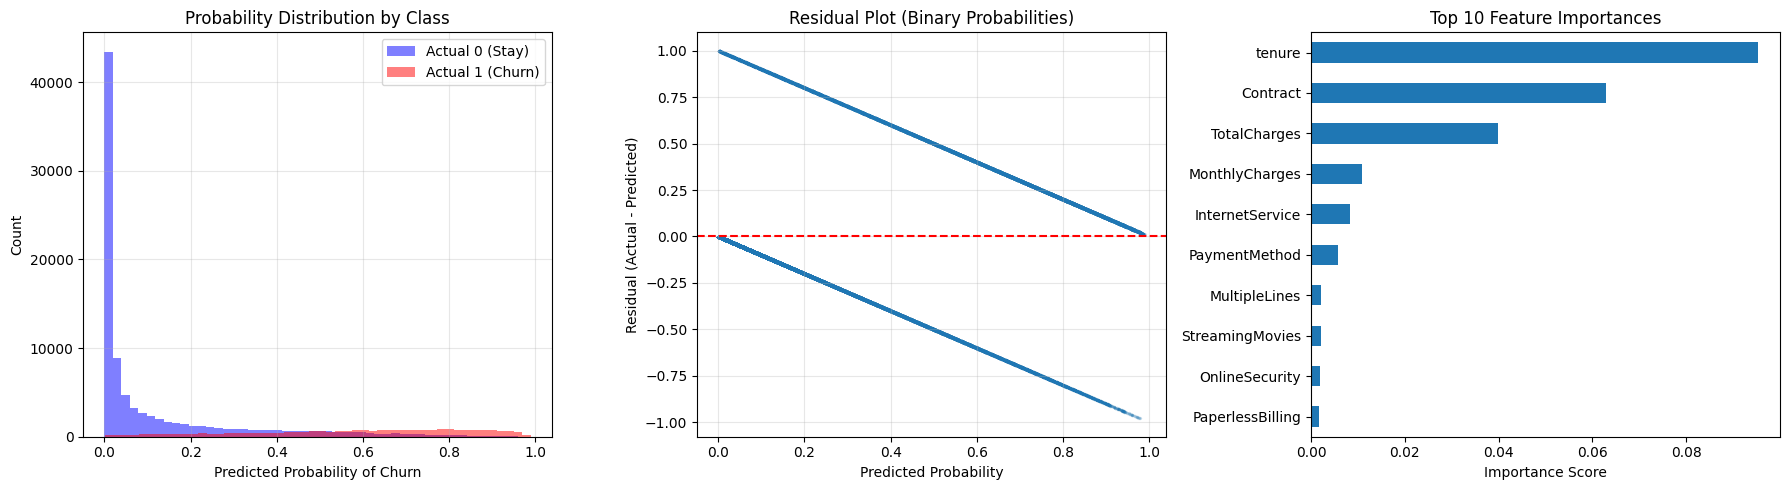

In [ ]:
# 7. Generate Visual Diagnostics
print("\nGenerating diagnostic plots...")

val_prob_all = predictor.predict_proba(val_data.drop(columns=target_column))
val_p1 = val_prob_all[positive_label]


y_val_numeric = y_val.map({'Yes': 1, 'No': 0})

plt.figure(figsize=(18, 5))

# Plot 1: Probability Distribution
plt.subplot(1, 3, 1)
plt.hist(val_p1[y_val_numeric == 0], bins=50, alpha=0.5, label='Actual 0 (Stay)',  color='blue')
plt.hist(val_p1[y_val_numeric == 1], bins=50, alpha=0.5, label='Actual 1 (Churn)', color='red')
plt.xlabel('Predicted Probability of Churn')
plt.ylabel('Count')
plt.title('Probability Distribution by Class')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual Plot
plt.subplot(1, 3, 2)
residuals = y_val_numeric - val_p1
plt.scatter(val_p1, residuals, alpha=0.1, s=2)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Probability')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot (Binary Probabilities)')
plt.grid(True, alpha=0.3)

# Plot 3: Feature Importance
plt.subplot(1, 3, 3)
try:
    importance = predictor.feature_importance(val_data)
    importance['importance'].abs().sort_values().tail(10).plot(kind='barh')
    plt.title('Top 10 Feature Importances')
    plt.xlabel('Importance Score')
except Exception as e:
    plt.text(0.5, 0.5, f"Could not calculate importance:\n{e}", ha='center', va='center')

plt.tight_layout()
plt.savefig('model_diagnostics.png')
plt.show()